### 10. 回帰分析

In [1]:
import pandas as pd

df = pd.read_csv("ch10/housing.data.txt", header=None, sep ="\s+")
df.columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

from mlxtend.plotting import scatterplotmatrix

Duplicate key in file PosixPath('/opt/anaconda3/lib/python3.11/site-packages/matplotlib/mpl-data/matplotlibrc'), line 273 ('font.serif:      DejaVu Serif, Bitstream Vera Serif, Computer Modern Roman, New Century Schoolbook, Century Schoolbook L, Utopia, ITC Bookman, Bookman, Nimbus Roman No9 L, Times New Roman, Times, Palatino, Charter, serif')
Duplicate key in file PosixPath('/opt/anaconda3/lib/python3.11/site-packages/matplotlib/mpl-data/matplotlibrc'), line 274 ('font.sans-serif: DejaVu Sans, Bitstream Vera Sans, Computer Modern Sans Serif, Lucida Grande, Verdana, Geneva, Lucid, Arial, Helvetica, Avant Garde, sans-serif')


ModuleNotFoundError: No module named 'mlxtend'

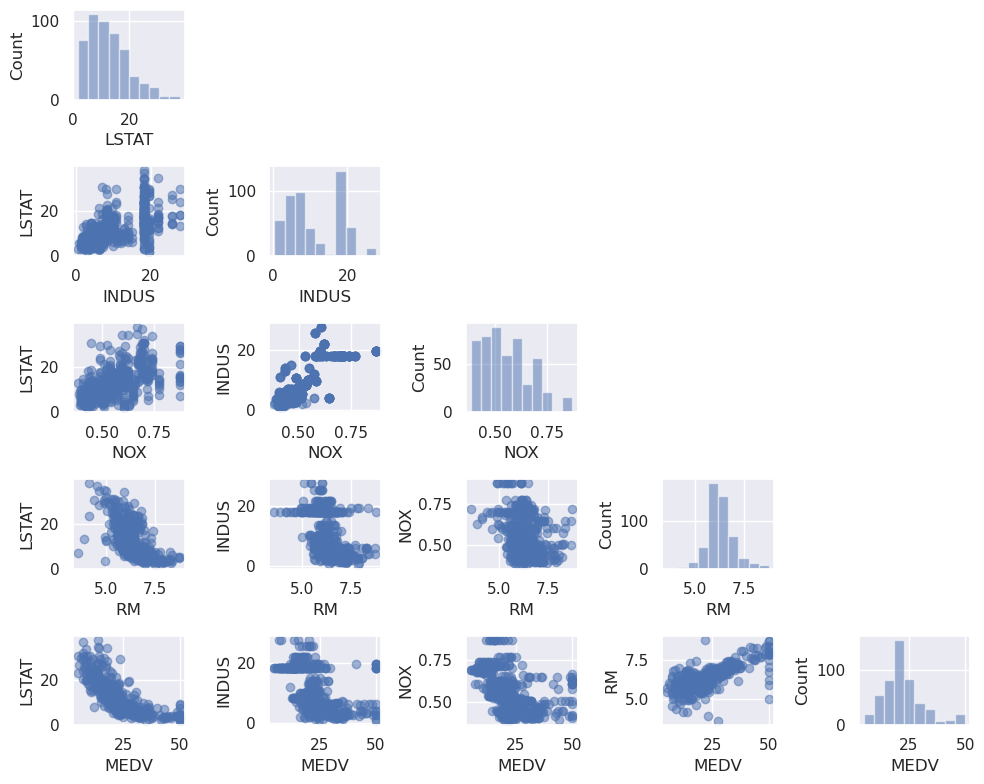

In [ ]:
cols = ["LSTAT","INDUS","NOX","RM","MEDV"]

scatterplotmatrix(df[cols].values, figsize =(10,8), names = cols, alpha = 0.5)
plt.tight_layout()
plt.show()

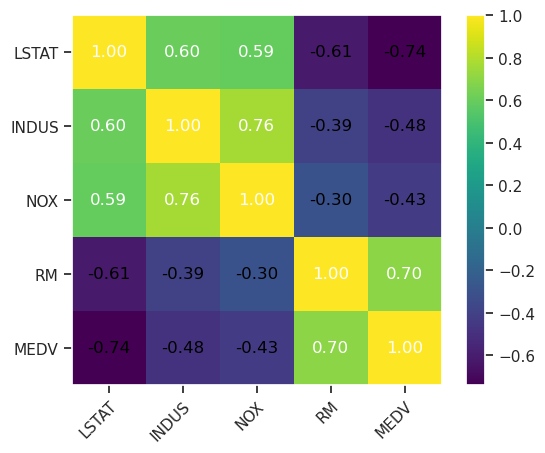

In [3]:
from mlxtend.plotting import heatmap
import numpy as np

cm = np.corrcoef(df[cols].values.T)

hm = heatmap(cm, row_names = cols, column_names = cols)
plt.show()

##### 標準化された特徴量の共分散と相関

相関係数rxyは　標準化されたxyの共分散に等しい

$r = \frac{\sigma_{xy}}{\sigma_x\sigma_y}$

$x\rightarrow x' = \frac{x-\mu_x}{\sigma_x}$とすると

$\sigma_{x'y'}=\frac{\sigma_{xy}}{\sigma_x\sigma_y}=r$

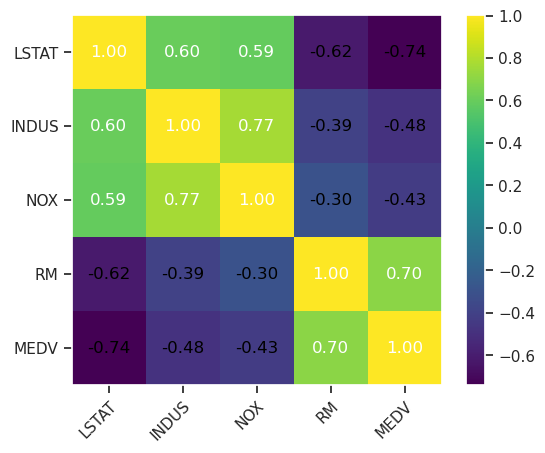

In [4]:
from sklearn.preprocessing import StandardScaler
scX = StandardScaler()

X_std = scX.fit_transform(df[cols])

cov_std = np.cov(X_std.T)
hm = heatmap(cov_std, row_names = cols, column_names = cols)
plt.show()


###### 10.3.1 最小二乗線形回帰モデルの実装

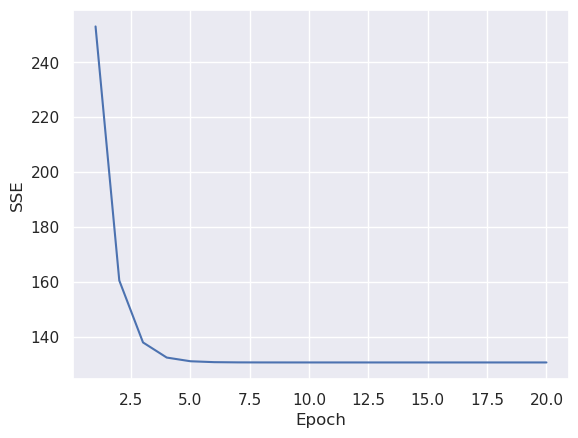

In [5]:
from ch10.LRGD import LinearRegressionGD
import numpy as np

X = df[["RM"]].values
y = df['MEDV'].values

from sklearn.preprocessing import StandardScaler


sc_x = StandardScaler()
sc_y = StandardScaler()

X_std = sc_x.fit_transform(X)
y_std = sc_y.fit_transform(y[:,np.newaxis]).flatten()

lr = LinearRegressionGD()

lr.fit(X_std, y_std)


plt.plot(range(1,lr.n_iter+1), lr.cost_)
plt.ylabel('SSE')
plt.xlabel("Epoch")
plt.show()


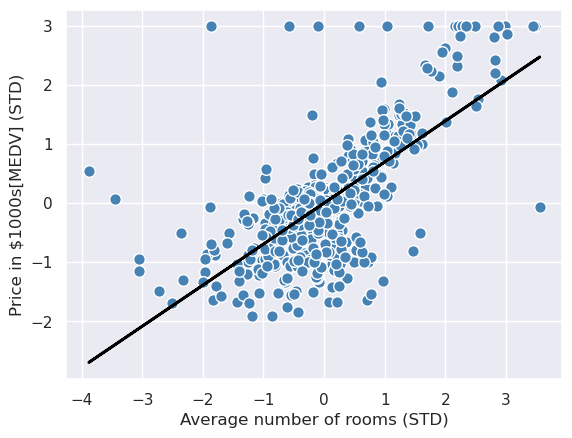

In [6]:
from common import lin_regplot

lin_regplot(X_std, y_std, lr)

plt.xlabel('Average number of rooms (STD)')
plt.ylabel('Price in $1000s[MEDV] (STD)')
plt.show()

##### 10.4 RANSACをもいいたロバスト回帰モデル


1. 正常値を用いてランダムな数のデータ点を選択し、モデルを学習させる
2. 学習済みのモデルに対し、その他すべてのデータ点を評価し、ユーザ指定の許容範囲となるデータ点を正常値に追加する。
3. すべての正常値を使ってモデルを再び学習させる。
4. 正常値に対する学習済みモデルの誤差を推定する。
5. モデルの性能がユーザ指定のしきい値の条件を満たしている場合、またはイテレーションが規定の回数に達した場合はアルゴリズムを終了する。そうでなければ手順1に戻る

In [7]:
from sklearn.linear_model import RANSACRegressor
from sklearn.linear_model import LinearRegression

ransac = RANSACRegressor(
  LinearRegression(),
  max_trials= 100,
  min_samples= 50,
  loss = 'absolute_error',
  residual_threshold = 5.0,
  random_state = 0
)


ransac.fit(X,y)

RANSACRegressor(estimator=LinearRegression(), min_samples=50, random_state=0,
                residual_threshold=5.0)

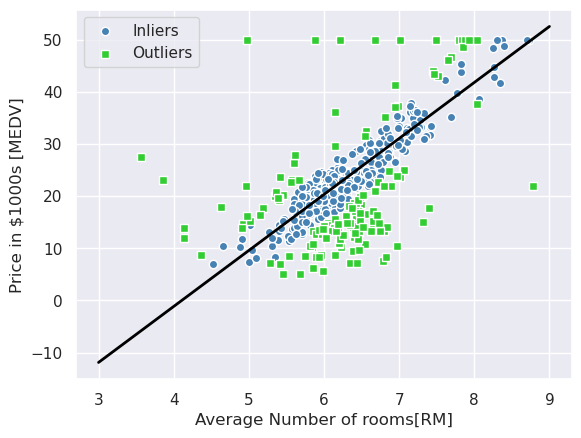

In [12]:
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

line_X = np.arange(3,10,1)
line_y_ransac = ransac.predict(line_X[:,np.newaxis])

plt.scatter(X[inlier_mask],y[inlier_mask],c='steelblue',edgecolor='white',marker = 'o', label = 'Inliers')
plt.scatter(X[outlier_mask],y[outlier_mask],c='limegreen',edgecolor='white',marker = 's', label = 'Outliers')

plt.plot(line_X, line_y_ransac, color = 'black', lw = 2)

plt.xlabel('Average Number of rooms[RM]')
plt.ylabel('Price in $1000s [MEDV]')
plt.legend(loc = 'upper left')
plt.show()


##### 線形回帰モデルの性能評価

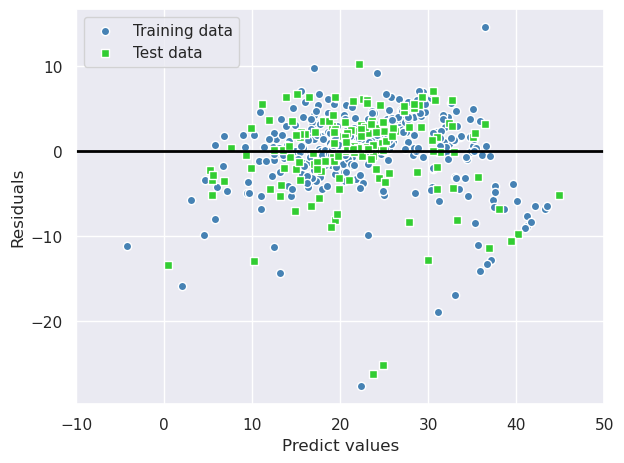

MSE Test: 19.958, Train: 27.196
R2 Test: 0.765, Train: 0.673


In [17]:
from sklearn.model_selection import train_test_split

X = df.iloc[:,:-1].values
y = df['MEDV'].values

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size = 0.3, random_state = 0
)

slr = LinearRegression()

slr.fit(X_train, y_train)

y_train_pred = slr.predict(X_train)
y_test_pred = slr.predict(X_test)

plt.scatter(y_train_pred, y_train_pred - y_train, c= 'steelblue',
            marker = 'o', edgecolor = 'white', label = 'Training data')

plt.scatter(y_test_pred, y_test_pred - y_test, c= 'limegreen',
            marker = 's', edgecolor = 'white', label = 'Test data')

plt.xlabel('Predict values')
plt.ylabel('Residuals')

plt.legend(loc = 'upper left')

plt.hlines(y = 0, xmin = -10, xmax = 50, color = 'black', lw = 2)

plt.xlim([-10,50])

plt.tight_layout()

plt.show()


#NOTE: 訓練データセットとテストデータセットの予測値の平均二乗誤差

from sklearn.metrics import mean_squared_error, r2_score

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)


r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)


print("MSE Test: %.3f, Train: %.3f"%(mse_train, mse_test))
print("R2 Test: %.3f, Train: %.3f"%(r2_train, r2_test))



In [24]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size = 0.3, random_state = 0
)


ransac = RANSACRegressor(
  LinearRegression(),
  max_trials= 1000,
  min_samples= 200,
  loss = 'absolute_error',
  residual_threshold = 1.0,
  random_state = 3
)


ransac.fit(X_train, y_train)

y_train_pred = ransac.predict(X_train)
y_test_pred = ransac.predict(X_test)

#RANSAC

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)


r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)


print("MSE Test: %.3f, Train: %.3f"%(mse_train, mse_test))
print("R2 Test: %.3f, Train: %.3f"%(r2_train, r2_test))

MSE Test: 20.672, Train: 27.758
R2 Test: 0.756, Train: 0.667


#### 正則化手法
